# Biopolymer 3D Printing LCA Pipeline (v2)
This notebook outlines a data pipeline to evaluate and optimize 3D-printed biopolymer construction products. The goal is to connect material recipes, life cycle assessment (LCA), spatial availability of feedstocks, and manufacturing constraints into one decision-support tool.

The pipeline is structured into four main modules:

1. General Morphological Analysis (GMA)  
2. Parameterization  
3. Spatial Analysis  
4. Optimization  

**Additions in v2:** 
- added two main processes (transportation) in LCA parameterization - this was surprisingly difficult. I [double checked the results on google sheets](https://docs.google.com/spreadsheets/d/1Bh_E6Dqw0YfCYrfy3eWVbMnPNf5n63-AkUeF_Qy_eAM/edit?gid=2140014812#gid=2140014812), they are correct, so the script works. 

**Aimed additions in next versions:**
- real biopolymer recipe
    - select real biopolymer recipe with Gabi 
    - link recipe components to ecoinvent processes  
    - include crop yield maps according to selected biopolymer recipe
- strength 
    - understand Gabi's biopol map strength matrix 
    - incorporate strength data for optimization  
    - implement dual-objective optimization (impact vs. strength) 


## 1. General Morphological Analysis

This section defines the design space for biopolymer recipes by combining different bio-based binders and fillers within specified percentage ranges. Instead of using a specialized morphological analysis package, we construct this logic directly in Python for transparency and flexibility.

The process includes three main steps:

1. **Creating input data**  
   Define the percentage ranges for each binder and filler (`biopol_ranges`) and generate all possible one-binder–one-filler combinations (`biopol_combinations`). These form the base design space, where feasibility can later be marked manually.

2. **Building the biopolymer matrix**  
   Construct a matrix where each row represents a binder (at percentage steps) and each column represents a filler (at percentage steps). Cells are marked with `0` if the binder–filler pair is feasible and their percentages add up to 100; otherwise, they remain `NaN`.

3. **Assigning dummy strength values**  
   Populate the feasible cells with dummy strength values that increase with both filler percentage and binder number, plus some random variation. This creates an illustrative dataset for later analysis.

Together, these steps generate a structured and parameterized view of all valid biopolymer formulations, forming the foundation for later stages like parameterization and optimization.


### Creating dummy input data for biopolymer recipes

This step sets up the basic input data used later in the analysis.

- **`biopol_ranges`** defines the percentage ranges for each binder and filler in a recipe.  
- **`biopol_combinations`** lists all possible one-binder–one-filler pairs, which can be marked as feasible or not in Excel.

Together, these tables describe the design space for biopolymer formulations.


In [11]:
import pandas as pd

# read Gabi's biopolymer recipes data 
biopol_ranges = pd.read_excel("data/dummy_numbers.xlsx", sheet_name="biopol_ranges")

# make cross consistency table (to be filled in)
binders = biopol_ranges[biopol_ranges["parameter"] == "binder"].copy()
fillers = biopol_ranges[biopol_ranges["parameter"] == "filler"].copy()
combinations = binders.merge(fillers, how="cross")
combos_df = pd.DataFrame({
    "id": combinations["id_x"] + "_" + combinations["id_y"],
    "binder": combinations["option_x"],
    "filler": combinations["option_y"]
})

# save cross consistency table in excel so it can be filled in 
file_path = 'data/dummy_numbers.xlsx'
sheet_name = 'biopol_combinations'

from openpyxl import load_workbook
wb = load_workbook(file_path)
if sheet_name not in wb.sheetnames: 
    with pd.ExcelWriter('data/dummy_numbers.xlsx', engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
        combos_df.to_excel(writer, sheet_name="biopol_combinations", index=False)
    print(f'Sheet {sheet_name} created.')
else: 
    print(f'Sheet {sheet_name} already exists, no changes made.')

# in excel: fill in the cross-consistency table 

# store biopol_ranges and biopol_combinations as csvs 
biopol_ranges.to_csv('data/processed/biopol_ranges.csv', index=False)
print(f'biopol_ranges saved as csv')
biopol_combos = pd.read_excel('data/dummy_numbers.xlsx', sheet_name='biopol_combinations')
biopol_combos.to_csv('data/processed/biopol_combinations.csv',  index=False)
print('biopol_combinations saved as csv')

Sheet biopol_combinations already exists, no changes made.
biopol_ranges saved as csv
biopol_combinations saved as csv


### Creating the biopolymer matrix

This step builds a matrix where each **row** represents a binder (at specific percentage steps) and each **column** represents a filler (also at percentage steps).

- The matrix starts with all values as `NaN`.  
- For each cell, we check whether the binder–filler pair is marked as feasible in `biopol_combos`, and whether their percentages add up to 100.  
- If both conditions are met, that cell is assigned a value of `0`; otherwise, it remains `NaN`.

The result is a matrix showing all valid binder–filler combinations as `0` and infeasible ones as empty (`NaN`).

In [12]:
import pandas as pd
import numpy as np

# Assumptions:
# - biopol_ranges has columns: ["id", "parameter", "option", "range_low", "range_high"]
# - biopol_combos has columns: ["id", "binder", "filler", "feasible"]
# - You already imported pandas and numpy.

############################################
# 1. Build the empty biopol_matrix (all NaN)
############################################

# Split binders and fillers
binders_df = biopol_ranges[biopol_ranges["parameter"] == "binder"].copy()
fillers_df = biopol_ranges[biopol_ranges["parameter"] == "filler"].copy()

# Generate row labels (binder_id_mass) and track binder_id and pct
row_labels = []
row_binder_ids = []
row_binder_masss = []

for _, row in binders_df.iterrows():
    b_id = row["id"]              # e.g. "b1"
    low = int(row["range_low"])   # e.g. 30
    high = int(row["range_high"]) # e.g. 60
    for pct in range(low, high + 1, 5):  # 30, 35, 40, ...
        row_labels.append(f"{b_id}_{pct}")
        row_binder_ids.append(b_id)
        row_binder_masss.append(pct)

# Generate column labels (filler_id_mass) and track filler_id and pct
col_labels = []
col_filler_ids = []
col_filler_masss = []

for _, row in fillers_df.iterrows():
    f_id = row["id"]              # e.g. "f1"
    low = int(row["range_low"])   # e.g. 20
    high = int(row["range_high"]) # e.g. 60
    for pct in range(low, high + 1, 5):  # 20, 25, 30, ...
        col_labels.append(f"{f_id}_{pct}")
        col_filler_ids.append(f_id)
        col_filler_masss.append(pct)

# Create the empty matrix with NaNs
biopol_matrix = pd.DataFrame(
    data=np.nan,
    index=row_labels,
    columns=col_labels
)

############################################
# 2. Build a fast lookup for feasibility
############################################

# We need to know which binder/filler pairs are feasible.
# biopol_combos currently has binder and filler as names like "potato_starch", "wood_fiber".
# We map them back to IDs like "b1", "f1" using biopol_ranges.

# Lookup tables: option name -> id
binder_name_to_id = dict(zip(binders_df["option"], binders_df["id"]))
filler_name_to_id = dict(zip(fillers_df["option"], fillers_df["id"]))

# Add binder_id and filler_id to biopol_combos
combos_labeled = biopol_combos.copy()
combos_labeled["binder_id"] = combos_labeled["binder"].map(binder_name_to_id)
combos_labeled["filler_id"] = combos_labeled["filler"].map(filler_name_to_id)

# Make a set of all feasible (binder_id, filler_id) pairs
feasible_pairs = {
    (row.binder_id, row.filler_id)
    for row in combos_labeled.itertuples(index=False)
    if row.feasible
}

############################################
# 3. Fill the matrix:
#    If pair feasible AND binder% + filler% == 100 -> set 0
#    else keep NaN
############################################

# We'll loop through the matrix using the tracking lists we already built
for row_label, b_id, b_mass in zip(biopol_matrix.index, row_binder_ids, row_binder_masss):
    for col_label, f_id, f_mass in zip(biopol_matrix.columns, col_filler_ids, col_filler_masss):

        # Check 1: is binder/filler pair feasible?
        is_feasible_pair = (b_id, f_id) in feasible_pairs

        # Check 2: do percentages sum to 100?
        sums_to_100 = (b_mass + f_mass == 100)

        if is_feasible_pair and sums_to_100:
            biopol_matrix.loc[row_label, col_label] = 0
        # else leave as NaN

# Remove rows and columns that are all NaN
biopol_matrix = biopol_matrix.dropna(how="all")
biopol_matrix = biopol_matrix.dropna(axis=1, how="all")

biopol_matrix_zeros = biopol_matrix 

### Filling the matrix with dummy strength values

This step assigns random dummy numbers to the feasible binder–filler combinations.  
The values don’t represent real data but illustrate how strength might vary:

- Higher **filler percentage** → higher strength.  
- Higher **binder number** (e.g., b3 stronger than b1) → higher strength.  
- A small random noise is added for variation.

The resulting matrix is saved as `biopol_strength_matrix.csv` for later use.

In [13]:
import numpy as np
import re

# Helper functions
def get_binder_num(label):
    """Extract numeric part of binder ID from row label like 'b2_40'."""
    return int(re.search(r"b(\d+)_", label).group(1))

def get_filler_mass(label):
    """Extract filler percentage from column label like 'f1_40'."""
    return int(re.search(r"_(\d+)$", label).group(1))

biopol_matrix = biopol_matrix_zeros.copy()

# Loop through every cell and fill zeros with dummy "strength" values
for row_label in biopol_matrix.index:
    binder_num = get_binder_num(row_label)
    for col_label in biopol_matrix.columns:
        if biopol_matrix.loc[row_label, col_label] == 0:
            filler_mass = get_filler_mass(col_label)
            
            # Dummy "strength" relationship:
            #   strength grows with both binder number and filler %
            #   plus a little random noise
            strength = binder_num * filler_mass + np.random.normal(0, 5)
            
            biopol_matrix.loc[row_label, col_label] = round(strength, 2)

biopol_matrix.to_csv('data/processed/biopol_strength_matrix.csv')
biopol_matrix

,f1_50,f1_55,f1_60,f1_65,f1_70,f1_75,f1_80,f1_85,f1_90,f2_45,...,f2_80,f3_50,f3_55,f3_60,f3_65,f3_70,f3_75,f3_80,f3_85,f3_90
b1_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.13,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.96
b1_15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.70,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.27,NaN
b1_20,NaN,NaN,NaN,NaN,NaN,NaN,78.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.87,NaN,NaN
b1_25,NaN,NaN,NaN,NaN,NaN,65.89,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,69.08,NaN,NaN,NaN
b1_30,NaN,NaN,NaN,NaN,61.48,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,75.38,NaN,NaN,NaN,NaN
b1_35,NaN,NaN,NaN,62.94,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,59.1,NaN,NaN,NaN,NaN,NaN
b1_40,NaN,NaN,56.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,65.29,NaN,NaN,NaN,NaN,NaN,NaN
b1_45,NaN,57.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,46.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
b1_50,46.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,50.97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
b2_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172.47,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Parameterization

ENVIRONMENTAL IMPACT PARAMETERIZATION 
- link ecoinvent data to all possible options using brightway keys 
- parameterize options into hierarchical structure of process, sub-process, and sub-sub-process 
- pre-calculate environmental impact of all parameterized options 

STRENGTH PARAMETERIZATION 
- link Gabi's biopol map to all possible options 

COMBINE PARAMETERS
- Combine environmental and strength result of all possible combinations 
- save into one df and csv 

### Environmental impact parameterization - simple LCA
with lcpy

In [14]:
from lcpy.calculators.helpers import ExchangeHolder, ImpactCalculator, ImpactHandler
from lcpy.calculators.bw_int import mpLCAer
import os
from lcpy.hvs.hvs import create_dataframe_dict, save_dataframes_to_excel, create_name_dictionaries,plot_stacked_percentage_bar_grid, plot_stacked_percentage_bar_sub_processes, plot_stacked_percentage_barchart_seaborn
from lcpy.hvs.map_dicts import create_mapping, create_list_with_unique_activities
from lcpy.hvs.hvs import make_characterized_inventory_dfs_simple_lca
from lcpy.calculators.env_calc import fast_calculator


#### Set up brightway project
- before running code below, setup brightway project in separate jupyter notebook, see `notebook_name.ipynb`
- define environmental impact calculation methods 
- link current notebook to previously set-up brightway project 
- **note:** be sure with work with `bw2`, **not** bw25. That's what is compatible with `lcpy`. 

Things that might be set-up incorrectly, leading the future bugs: 
- `brightway_configuration_dictionary`: I'm not sure if `path_to_brightway_project` is correct.

In [15]:
target_dir = "results/lca"
os.makedirs(target_dir, exist_ok=True)

# define environmental impact calculation methods (e.g. TRACI v2.1)
methods_list = [
('TRACI v2.1', 'acidification', 'acidification potential (AP)'),
('TRACI v2.1', 'climate change', 'global warming potential (GWP100)'),
('TRACI v2.1', 'ecotoxicity: freshwater', 'ecotoxicity: freshwater'),
('TRACI v2.1', 'eutrophication', 'eutrophication potential'),
('TRACI v2.1', 'human toxicity: carcinogenic', 'human toxicity: carcinogenic'),
('TRACI v2.1', 'human toxicity: non-carcinogenic', 'human toxicity: non-carcinogenic'),
('TRACI v2.1', 'ozone depletion', 'ozone depletion potential (ODP)'),
('TRACI v2.1', 'particulate matter formation', 'particulate matter formation potential (PMFP)'),
('TRACI v2.1', 'photochemical oxidant formation', 'maximum incremental reactivity (MIR)'),
]
method_units_list = ['kg SO2-Eq',
 'kg CO2-Eq',
 'CTUe',
 'kg N-Eq',
 'CTUh',
 'CTUh',
 'kg CFC-11-Eq',
 'kg PM2.5-Eq',
 'kg O3-Eq',
]

# link to brightway - folder name for bw environment, project name, database names, etc. 
brightway_configuration_dictionary = {
    # path_to_folder_containing_the_bw_environment_and_packages_installed_there
    "path_to_brightway_project": "/Users/tsuitpy/Library/Application Support/Brightway3/biopol_lca.967046090aaaeb21fcd35d8654c4df5a", 
    "bw_project": "biopol_lca",
    "bw_database": "biopol_lca_database", 
    "bw_biosphere": "ecoinvent-3.9.1-biosphere",
    "bw_ecoinvent": "ecoinvent-3.9.1-cutoff"
}
methods_gp = methods_list[:]
impact_categories_names = ['AP', 'GWP100', 'ECFW', 'EP', 'HTC', 'HTNC', 'ODP', 'PMFP', 'MIR']
impact_categories_units = method_units_list
scenarios = 100
timeframe = 1 #operational lifetime after construction
time_step = 1
construction_years = 0
number_of_infrastructure_processes = 0
# scenario_names = ['one']
# timeframe = 2 #operational lifetime after construction
# time_step = 1
# construction_years = 0


#### Define parametric model 

In [16]:
# sub-sub-processes: values to be adjusted according to recipe 
b1_potato_starch_mass = 40
b2_lignin_resin_mass = 0
b3_soy_resin_mass = 0
f1_wood_fiber_mass = 60
f2_hemp_shiv_mass = 0
f3_rice_husk_mass = 0 

# sub-processes 
binder_mass = b1_potato_starch_mass + b2_lignin_resin_mass + b3_soy_resin_mass
filler_mass = f1_wood_fiber_mass + f2_hemp_shiv_mass + f3_rice_husk_mass 

# main process 
total_mass = binder_mass + filler_mass

#### Filling in the bw keys. 
Issues to be fixed / adjusted: 
- right now, we are using keys for 'market for ...' which includes average transportation distances. We will want to model these transportation distances ourselves. 
- these biopol ingredients also need somekind of pre-processing, for example turning potatoes into potato starch. So it's not as simple as collecting potatoes from the field and immediately throwing them into a 3D printer. There's an intermediate step, where the potatoes need to go to some kind of factory to be made into starch, and then transported to our 3D printer. 
- can't find ecoinvent activities for most of the binders and fillers, so using dummy numbers for now

In [7]:
# handy script for searching for ecoinvent keys 
from bw2data import Database
activity_name = "market for transport, freight, lorry, unspecified"
db = Database("ecoinvent-3.9.1-cutoff")  # or whatever your database is called
for act in db:
    if activity_name in act['name'].lower():
        print(act)
        print(act.key)

In [17]:
# sub-processes + sub-sub-processes 
keys_binder = {
    # matches each binder ingredient (b1, b2, b3) to a bw key 
    'b1_potato_starch_mass' : '8ce68e5f71f8f8c5dc50edb913e9cea1', # market for potato starch ('ecoinvent-3.9.1-cutoff', '8ce68e5f71f8f8c5dc50edb913e9cea1')
    'b2_lignin_resin_mass': '9ef63345ae414b0aa5683f09f4d0b806', # 'market for anionic resin' (kilogram, RER, None)
    'b3_soy_resin_mass': '16a6869a94ad2aaf84d113c88657406b' # 'market for phenolic resin' (kilogram, RER, None) 
}
binder_exchanges_amounts = [ 
    # proportion of binder ingredients (b1, b2, b3) in the binder
    # looks something like this: [1.0, 0.0, 0.0]
    # order of the amounts matches with keys_binder 
    b1_potato_starch_mass / binder_mass, 
    b2_lignin_resin_mass / binder_mass, 
    b3_soy_resin_mass / binder_mass
] 
keys_filler = {
    # matches each filler ingredient (f1, f2, f3) to a bw key 
    'f1_wood_fiber_mass' : 'd82e94ec45e662362de31d0ac344dc51', # 'market for wood wool' (kilogram, RER, None) 
    'f2_hemp_shiv_mass': 'b8b0f0ca4e8e1a99ddae3f6ae610be2e', # 'market for sunn hemp plant, harvested' (kilogram, GLO, None)
    'f3_rice_husk_mass': '94c1cb9e760faf73987ffea6c08cfcf1' # 'market for coconut husk' (kilogram, GLO, None) 
}
filler_exchanges_amounts = [
    # proportion of filler ingredients (b1, b2, b3) in the filler
    # looks something like this: [1.0, 0.0, 0.0]
    # order of the amounts matches with keys_filler  
    f1_wood_fiber_mass / filler_mass, 
    f2_hemp_shiv_mass / filler_mass, 
    f3_rice_husk_mass / filler_mass 
]

# main process + sub-processes 
keys_main_process = {
    # sub-processes for the recipe 
    'binder': '', 
    'filler': '' 
}
main_process_exchanges_amounts = [ 
    # proportion of recipe ingredients (binder, filler) in the recipe 
    # looks something like this: [0.4, 0.6]
    # order of amounts matches keys_main_process 
    binder_mass / total_mass, 
    filler_mass / total_mass 
]

#### Link keys to lca calculator

In [18]:
# linking main process, sub-processes, and sub-sub-processes 

# list out all the brightway keys of the sub-processes 
# for us this is the binders (b1, b2, b3) and the fillers (f1, f2, f3) 
key_list_sub_processes = [keys_binder, keys_filler]

# list out all the exchanges of the sub-processes 
# for us this is the binders (b1, b2, b3) and the fillers (f1, f2, f3) 
# looks a bit like this: [[1.0, 0.0, 0.0], [1.0, 0.0, 0.0]]
exchanges_list_sub_processes = [binder_exchanges_amounts, filler_exchanges_amounts]

# map names: 
# keys_recipe = {'binder': '', 'filler': ''}
# key_list_sub_processes = 
# [
#     {
#         'b1_potato_starch_mass': '8ce68e5f71f8f8c5dc50edb913e9cea1',
#         'b2_lignin_resin_mass': '9ef63345ae414b0aa5683f09f4d0b806',
#         'b3_soy_resin_mass': '16a6869a94ad2aaf84d113c88657406b'
#     },
#     {
#         'f1_wood_fiber_mass': 'd82e94ec45e662362de31d0ac344dc51',
#         'f2_hemp_shiv_mass': 'b8b0f0ca4e8e1a99ddae3f6ae610be2e',
#         'f3_rice_husk_mass': '94c1cb9e760faf73987ffea6c08cfcf1'
#     }
# ]
mapping_names = create_mapping(keys_main_process, key_list_sub_processes)
unique_activities = create_list_with_unique_activities(key_list_sub_processes)

# map exchanges: 
# keys_recipe = {'binder': '', 'filler': ''}
# exchanges_list_sub_processes = [[1.0, 0.0, 0.0], [1.0, 0.0, 0.0]]
mapping_exchanges = create_mapping(keys_main_process, exchanges_list_sub_processes)

# create mapping dictionaries of main process 
main_process_names = ['Recipe Production']
mapping_exchanges_mp = {main_process_names[0]: main_process_exchanges_amounts}
names_dictionary = create_name_dictionaries(mapping_names, key_list_sub_processes)
names_dictionary_graphite_main = {main_process_names[0]: list(names_dictionary.keys())}

# what comes out: 
# mapping_exchanges_mp = {'Recipe Production': [0.4, 0.6]}
# names_dictionary = 
# {'binder': ['b1_potato_starch_mass', 'b2_lignin_resin_mass', 'b3_soy_resin_mass'],
# 'filler': ['f1_wood_fiber_mass', 'f2_hemp_shiv_mass', 'f3_rice_husk_mass']}

#### Run LCA
- Calculates the unit impact, inventories, and characterized inventories, for each sub-sub-process in each sub-process.
- The impact, inventory, and characterized inventory values are stored in dictionaries of the my_lca object.

In [19]:
# run LCA calculations
my_lca = mpLCAer(4, methods_gp, brightway_configuration_dictionary)
my_lca.import_isolated_environment()
my_lca.lca_calculations(mapping_names)

In [20]:
# HANDLE SUB-PROCESSES (sp = sub-process)

# calculate unit impact of each sub-process (binder, filler)
# based on exchanges with sub-sub-processes (b1_potato_starch, etc)
sp_exchange_manager = ExchangeHolder(methods_gp) # biosphere exchanges based on pre-defined impact calculation methods 
sp_exchange_manager.create_exchange_arrays(mapping_exchanges) # manage exchanges from sub-sub-processes to sub-processes
sp_impact_calculator = ImpactCalculator()
sp_impact_calculator.impact_calculation_simple(my_lca.unit_impacts, sp_exchange_manager.exchanges_dict) # calculate unit impacts based on exchanges

# store impact results for sub-processes 
sp_results_handler = ImpactHandler(impact_categories_names)
sp_results_handler.create_dataframes(sp_impact_calculator.simple_impacts, names_dictionary)

# scale sub-process unit results for sub-processes with exchange amounts for main process
mp_results_handler = ImpactHandler(impact_categories_names)
mp_results_handler.calculate_total_unit_impact(sp_results_handler.total_impact_arrays, main_process_names[0])


In [21]:
# HANDLE MAIN PROCESS (mp = main process)

# calculate unit impact of main process (recipe)
# based on exchanges with sub-processes (binder, filler)
mp_exchange_manager = ExchangeHolder(methods_gp) # biosphere exchanged based on pre-defined impact calculation method (e.g. TRACI)
mp_exchange_manager.create_exchange_arrays(mapping_exchanges_mp) # manage exchanges from sub-processes to main process
mp_impact_calculator = ImpactCalculator()
mp_impact_calculator.impact_calculation_simple(mp_results_handler.total_unit_impact, mp_exchange_manager.exchanges_dict)

# store impact results for main process 
mp_results_handler.create_dataframes(mp_impact_calculator.simple_impacts, names_dictionary_graphite_main)


In [22]:
# SUMMARIZE AND SAVE RESULTS 

# create dictionary of dfs with contribution analysis results 
df_list_results = list(sp_results_handler.df_contributions.values())
df_list_results.append(mp_results_handler.df_contributions['Recipe Production'])
sheet_names = list(keys_main_process.keys()) + ['Total'] # Names of excel sheet for storage
dict_with_contribution_dfs = create_dataframe_dict(df_list_results, sheet_names)

# create list of dfs with sub-process and main-process results 
# and put in dictionary 
list_with_absolute_results = list(sp_results_handler.df_impacts.values())
list_with_absolute_results.append(mp_results_handler.df_impacts['Recipe Production'])
dict_with_absolute_results_df = create_dataframe_dict(list_with_absolute_results, sheet_names)

# save results in excel 
excel_file_path_contribution_results = os.path.join(target_dir, 'Recipe Production.xlsx')
excel_file_path_absolute_results = os.path.join(target_dir, 'Totals_graphite.xlsx')
save_dataframes_to_excel(dict_with_contribution_dfs, excel_file_path_contribution_results)
save_dataframes_to_excel(dict_with_absolute_results_df, excel_file_path_absolute_results)


Excel file 'results/lca/Recipe Production.xlsx' saved successfully.
Excel file 'results/lca/Totals_graphite.xlsx' saved successfully.


#### Add transportation as another process 
- make biopol recipe main process into a sub-process 
- add transportation as a sub-process 
- main process becomes: 3D printed biopolymer 

In [23]:
keys_binder = {
    'b1_potato_starch_mass' : '8ce68e5f71f8f8c5dc50edb913e9cea1', # market for potato starch ('ecoinvent-3.9.1-cutoff', '8ce68e5f71f8f8c5dc50edb913e9cea1')
    'b2_lignin_resin_mass': '9ef63345ae414b0aa5683f09f4d0b806', # 'market for anionic resin' (kilogram, RER, None)
    'b3_soy_resin_mass': '16a6869a94ad2aaf84d113c88657406b' # 'market for phenolic resin' (kilogram, RER, None) 
}
keys_filler = {
    'f1_wood_fiber_mass' : 'd82e94ec45e662362de31d0ac344dc51', # 'market for wood wool' (kilogram, RER, None) 
    'f2_hemp_shiv_mass': 'b8b0f0ca4e8e1a99ddae3f6ae610be2e', # 'market for sunn hemp plant, harvested' (kilogram, GLO, None)
    'f3_rice_husk_mass': '94c1cb9e760faf73987ffea6c08cfcf1' # 'market for coconut husk' (kilogram, GLO, None) 
}
keys_recipe = {
    'binder': '', 
    'filler': '' 
}

key_list_sub_processes = [keys_binder, keys_filler]
mapping_names = create_mapping(keys_recipe, key_list_sub_processes)
unique_activities = create_list_with_unique_activities(key_list_sub_processes)

my_lca = mpLCAer(4, methods_gp, brightway_configuration_dictionary)
my_lca.import_isolated_environment()
my_lca.lca_calculations(mapping_names)

In [24]:
# model biopol recipe separately as its own dictionary and list 
key_recipe = {
    'Recipe Production': ''
}
exchange_list_recipe = [1] # 1kg of biopol ingredients = 1kg of printed biopol (for now, simple example)

# model other sub-process(s) - in our case, transportation 
transportation_distance_km = 10 # defined by spatial analysis 
key_transportation = {
    'transportation': '9f5ff656ecdc15acd23085211786936f' 
}
exchange_list_transportation = [transportation_distance_km]

# model new main process - biopol 3d print production 
key_biopol_3dprint_production = {
    'Transportation': '', 
}
exchange_list_biopol_3dprint_production = [1]


In [25]:
key_list_new_main_process = [key_transportation]
exchanges_list_new_main_process = [exchange_list_transportation]

mapping_new_main_process = create_mapping(key_biopol_3dprint_production, key_list_new_main_process)
unique_activities_new_main_process = create_list_with_unique_activities(key_list_new_main_process)
mapping_each_new_main_process = create_mapping(key_biopol_3dprint_production, exchanges_list_new_main_process)

my_lca_new_main_process = mpLCAer(4, methods_gp, brightway_configuration_dictionary)
my_lca_new_main_process.import_isolated_environment()
my_lca_new_main_process.lca_calculations(mapping_new_main_process)


In [26]:
mapping_new_main_process.keys()

dict_keys(['Transportation'])

In [27]:
my_lca_new_main_process.unit_impacts

{'Transportation': array([[4.16404006e-04, 1.41896635e-01, 1.28912783e+00, 1.14120326e-04,
         1.03015172e-08, 3.31454746e-08, 3.34497549e-09, 7.58738798e-05,
         1.08835144e-02]])}

In [28]:
mapping_each_new_main_process

{'Transportation': [10]}

We have now calculated the unit_impacts for the other sub-processes. Here we will make some appends to the created lists/dataframes/dictionaries to include the previously calculated process. The same steps can be repeated to include non-bw based processes in the lcpy analysis (e.g., processes the impact/inventory of which are precalculated from another software). We do:

1) First, we append the unit_impacts we calculated in the previous modelling
2) Second, we append the mapping dictionary:
3) Third, we append the mapping_exchanges_dictionary:
4) Forth, we append the key_list_production_new_main_process list that holds the mapping dicitonaries for each sub-process
5) Fifth, we append the exchanges_list_production_new_main_process list that holds the exchanges amounts in lists for each each sub-process. We do not need to do that in principle, since we have already appended the required in the mapping_exch_new_main_process dictionary, but we do it for consistency and for better inspection
6) Sixth, we append the dictionaries of the new main process

In [29]:
my_lca_new_main_process.unit_impacts['Recipe Production'] = mp_results_handler.total_impact_arrays['Recipe Production'].reshape(1, len(impact_categories_names))
mapping_new_main_process['Recipe Production'] = ['']
mapping_each_new_main_process['Recipe Production'] = [1.] # in case of multiple scenarios and time_steps the 1. should be an array
key_list_new_main_process.append({'Recipe Production': ''})
exchanges_list_new_main_process.append([1.])

key_biopol_3dprint_production['Recipe Production'] = ['']
exchange_list_biopol_3dprint_production.append(1.)

Once these appends are done, the subsequent modelling remains the same

In [30]:
sp_exchange_new_main_process = ExchangeHolder(methods_gp)
sp_impact_new_main_process = ImpactCalculator()

sp_exchange_new_main_process.create_exchange_arrays(mapping_each_new_main_process)
sp_impact_new_main_process.impact_calculation_simple(my_lca_new_main_process.unit_impacts, sp_exchange_new_main_process.exchanges_dict)
sp_handler_new_main_process = ImpactHandler(impact_categories_names)
names_dictionary_new_main_process = create_name_dictionaries(mapping_new_main_process, key_list_new_main_process)
sp_handler_new_main_process.create_dataframes(sp_impact_new_main_process.simple_impacts, names_dictionary_new_main_process)
total_handler_new_main_process = ImpactHandler(impact_categories_names)

list_with_names_of_new_main_process = ['New main process']
total_handler_new_main_process.calculate_total_unit_impact(sp_handler_new_main_process.total_impact_arrays, list_with_names_of_new_main_process[0])
total_exchanger_new_main_process = ExchangeHolder(methods_gp)
total_impact_calculator_new_main_process = ImpactCalculator()

mapping_exch_total_new_main_process = {list_with_names_of_new_main_process[0]: exchange_list_biopol_3dprint_production}
names_dictionary_new_main_process_main = {list_with_names_of_new_main_process[0]: list(names_dictionary_new_main_process.keys()) }

total_exchanger_new_main_process.create_exchange_arrays(mapping_exch_total_new_main_process)
total_impact_calculator_new_main_process.impact_calculation_simple(total_handler_new_main_process.total_unit_impact, total_exchanger_new_main_process.exchanges_dict)
total_handler_new_main_process.create_dataframes(total_impact_calculator_new_main_process.simple_impacts, names_dictionary_new_main_process_main)

df_list_new_main_process = list(sp_handler_new_main_process.df_contributions.values())
df_list_new_main_process.append(total_handler_new_main_process.df_contributions['New main process'])

sheet_names_new_main_process = list(key_biopol_3dprint_production.keys()) + ['Total']
dict_with_dfs_contr_new_main_process = create_dataframe_dict(df_list_new_main_process, sheet_names_new_main_process)
df_list_total_new_main_process = list(sp_handler_new_main_process.df_impacts.values())
df_list_total_new_main_process.append(total_handler_new_main_process.df_impacts['New main process'])
dict_with_dfs_total_new_main_process = create_dataframe_dict(df_list_total_new_main_process, sheet_names_new_main_process)

excel_file_path_contr_new_main_process = os.path.join(target_dir, 'Contributions_new_main_process.xlsx')
save_dataframes_to_excel(dict_with_dfs_contr_new_main_process, excel_file_path_contr_new_main_process)

excel_file_path_total_new_main_process = os.path.join(target_dir, 'Totals_new_main_process.xlsx')
save_dataframes_to_excel(dict_with_dfs_total_new_main_process, excel_file_path_total_new_main_process)
sp_handler_new_main_process.contribution_to_total_impact_per_sub_sub_processes(dict_with_dfs_total_new_main_process, dict_with_dfs_contr_new_main_process, unique_activities_new_main_process, name= 'new main process', target_dir = target_dir)


Excel file 'results/lca/Contributions_new_main_process.xlsx' saved successfully.
Excel file 'results/lca/Totals_new_main_process.xlsx' saved successfully.


## 3. Spatial Analysis

We created a set of spatial datasets for analysis:

1. **Crop Yield Map (`data/processed/EU_crop_map_yield.tif`)**  
   Generated from a small sample of the EU Crop Map using dummy data on crop types and their annual yields to estimate yield per pixel.

2. **Factory Locations Map (`data/processed/factory_locations.tif`)**  
   Created by randomly selecting 10 pixels as potential factory sites, aligned with the crop yield map.

3. **Distance Matrix (`data/processed/factory_to_crop_distances.feather`)**  
   Computed Euclidean distances between all crop pixels and factory locations, storing the results in a binary format for efficient analysis.

These datasets together form the foundation for spatial analysis of crop production and potential factory siting.



### EU crop map - random sample
- get random clipped sample of `data/EU_crop_map.tif` that has multiple crop types
- save as `data/EU_crop_map_sample.tif

EU crop map can be downloaded [here](https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/EUCROPMAP/2022/), paper about the dataset can be found [here](https://www.nature.com/articles/s41597-024-03884-y). Right now I just downloaded a random tile, but later I'll download the whole EU 
`

Raster size: 32768 × 32768
✅ Found mixed area at offset (24623, 22219)
Unique crop codes: [100 211 213 216 217 219 221 222 231 232]


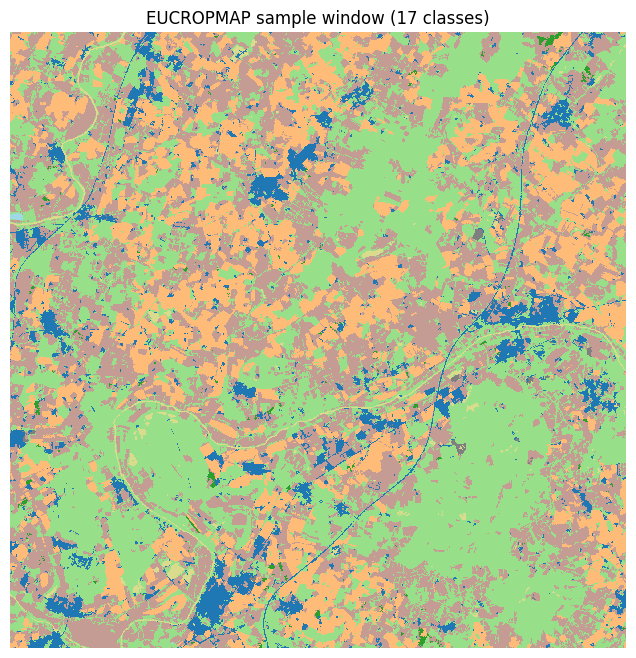

💾 Saved cropped GeoTIFF to: data/EU_crop_map_sample.tif


In [6]:
import rasterio
from rasterio.windows import Window
import numpy as np
import matplotlib.pyplot as plt
import random

# === SETTINGS ===
path = "data/EU_crop_map.tif"
out_path = "data/EU_crop_map_sample.tif"
window_size = 2000

# === FIND RANDOM WINDOW WITH VARIATION ===
with rasterio.open(path) as src:
    width, height = src.width, src.height
    print(f"Raster size: {width} × {height}")

    found = False
    attempts = 0

    while not found and attempts < 20:  # try up to 20 random spots
        col_off = random.randint(0, width - window_size)
        row_off = random.randint(0, height - window_size)
        window = Window(col_off, row_off, window_size, window_size)

        data_small = src.read(1, window=window)
        unique_vals = np.unique(data_small)

        if len(unique_vals) > 1:  # found variation
            found = True
            print(f"✅ Found mixed area at offset ({col_off}, {row_off})")
            print(f"Unique crop codes: {unique_vals[:10]}")
        attempts += 1

    if not found:
        raise ValueError("⚠️ No variation found — try another tile.")

    # === VISUALIZE ===
    plt.figure(figsize=(8, 8))
    plt.imshow(data_small, cmap="tab20", interpolation="nearest")
    plt.title(f"EUCROPMAP sample window ({len(unique_vals)} classes)")
    plt.axis("off")
    plt.show()

    # === SAVE CROPPED TILE ===
    transform = src.window_transform(window)
    profile = src.profile
    profile.update({
        "height": window_size,
        "width": window_size,
        "transform": transform
    })

    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(data_small, 1)

print(f"💾 Saved cropped GeoTIFF to: {out_path}")


### Crop yield table for biopol ingredients 
- get top 6 crop codes (by area) from `data/EU_crop_map_sample.tif`
- assign these codes to biopol ingredients in `data/processed/biopol_ranges.csv`
- for each biopol ingredient, make up dummy annual yield values (kg/m2) 
- save as `data/processed/biopol_ranges_with_feedstocks.csv`

In [7]:
import rasterio
import numpy as np
import pandas as pd

# ----------------------------------------
# 1. Read the cropped EUCROPMAP sample
# ----------------------------------------
raster_path = "data/EU_crop_map_sample.tif"

with rasterio.open(raster_path) as src:
    arr = src.read(1)  # crop class codes
    res_x, res_y = src.res  # pixel size in meters (should be 10 x 10)
    pixel_area_m2 = res_x * res_y

# all unique codes + how many pixels
vals, counts = np.unique(arr, return_counts=True)

# compute area per class in m²
areas_m2 = counts * pixel_area_m2

# pair them up
code_area_pairs = list(zip(vals, areas_m2))

# sort by area descending, ignore code==0 (0 is usually no data / outside AOI)
code_area_pairs = [p for p in code_area_pairs if p[0] != 0]
code_area_pairs.sort(key=lambda x: x[1], reverse=True)

# take top 6 crop codes
top_codes = [code for code, area in code_area_pairs[:6]]

print("Top 6 codes by area:", top_codes)

# ----------------------------------------
# 2. Build dummy yield data for those codes
# ----------------------------------------
# We'll just generate a decreasing gradient of plausible-ish yields.
# Interpretation: kg/m² ~ tonnes/ha / 10. So 2.5 kg/m² ~ 25 t/ha.
base_yields = np.linspace(2.5, 1.0, num=len(top_codes))  # length matches however many codes we actually got

dummy_yield_dict = {code: float(y) for code, y in zip(top_codes, base_yields)}

# print("Dummy yields (kg/m²):")
# for c in top_codes:
#     print(f"  code {c}: {dummy_yield_dict[c]} kg/m²")

# ----------------------------------------
# 3. Load bipol_ranges and assign codes/yields
# ----------------------------------------
# Expected columns: id, parameter, option, range_low, range_high
df = pd.read_csv("data/processed/biopol_ranges.csv")

# We want an alternating assignment:
# order of rows we care about for assignment:
# b1, f1, b2, f2, b3, f3
# We'll infer that order programmatically from df:
#   - sort binders by id order b1,b2,b3,...
#   - sort fillers by id order f1,f2,f3,...
#   - then weave them [b1,f1,b2,f2,b3,f3,...]

binders = df[df["parameter"].str.lower() == "binder"].sort_values("id").copy()
fillers = df[df["parameter"].str.lower() == "filler"].sort_values("id").copy()

# weave them
weaved_rows = []
for b_row, f_row in zip(binders.index.tolist(), fillers.index.tolist()):
    weaved_rows.append(b_row)
    weaved_rows.append(f_row)

# If lengths mismatch (e.g. more binders than fillers or vice versa),
# append the extras at the end
extra_binders = binders.index.tolist()[len(fillers):]
extra_fillers = fillers.index.tolist()[len(binders):]
weaved_rows.extend(extra_binders)
weaved_rows.extend(extra_fillers)

# Now weaved_rows is the row index order we want to assign top_codes to.
# Example: [index_of_b1, index_of_f1, index_of_b2, index_of_f2, index_of_b3, index_of_f3]

# Sanity: we only assign up to however many top codes we actually have
assignable_count = min(len(weaved_rows), len(top_codes))

# Prepare new columns
df["eu_crop_code"] = np.nan
df["yield_kg_m2"] = np.nan

for i in range(assignable_count):
    row_idx = weaved_rows[i]
    crop_code = top_codes[i]
    df.loc[row_idx, "eu_crop_code"] = crop_code
    df.loc[row_idx, "yield_kg_m2"] = dummy_yield_dict[crop_code]
df.eu_crop_code = df.eu_crop_code.map(lambda x: int(x))

# ----------------------------------------
# 4. Save
# ----------------------------------------
out_csv_path = "data/processed/bipol_ranges_with_feedstocks.csv"
df.to_csv(out_csv_path, index=False)

print(f"\n✅ Wrote updated table with feedstocks to {out_csv_path}\n")
df


Top 6 codes by area: [300, 500, 211, 216, 100, 231]

✅ Wrote updated table with feedstocks to data/processed/bipol_ranges_with_feedstocks.csv



,id,parameter,option,range_low,range_high,eu_crop_code,yield_kg_m2
0,b1,binder,potato_starch,30,60,300,2.5
1,b2,binder,lignin_resin,25,55,211,1.9
2,b3,binder,soy_resin,35,65,100,1.3
3,f1,filler,wood_fiber,20,60,500,2.2
4,f2,filler,hemp_shiv,15,50,216,1.6
5,f3,filler,rice_husk,10,40,231,1.0


### Crop yield map 
- double check area of each pixel (100 m2)
- calculate annual yield (kg) for each pixel according to crop code 
- write annual yield values as another layer in the raster 
- save raster as `data/processed/EU_crop_map_yield.tif`

In [12]:
import rasterio
import numpy as np
import pandas as pd

# --- inputs ---
in_path  = "data/EU_crop_map_sample.tif"   # original crop code raster
out_path = "data/processed/EU_crop_map_yield.tif"    # final 3-band product

# df must have: df["eu_crop_code"], df["yield_kg_m2"]

# --- read crop code raster and metadata ---
with rasterio.open(in_path) as src:
    crop_codes = src.read(1)          # 2D array of crop codes (ints)
    transform = src.transform
    profile = src.profile             # to reuse for writing
    crs = src.crs
    src_nodata = src.nodata           # may be None
    height, width = crop_codes.shape

# --- compute pixel area in m^2 ---
# assumes CRS is in meters; if CRS is degrees, reproject first (see earlier note)
pixel_w = transform.a        # pixel size in x direction
pixel_h = -transform.e       # pixel size in y direction (negative in north-up rasters)
pixel_area_m2 = pixel_w * pixel_h
print("Pixel area (m2):", pixel_area_m2)

# --- build lookup from crop code -> yield (kg/m2/year) ---
lookup = dict(zip(df["eu_crop_code"].to_numpy(), df["yield_kg_m2"].to_numpy()))

# --- map per-pixel yield rate ---
yield_rate_per_m2 = np.full(crop_codes.shape, np.nan, dtype="float32")

unique_codes = np.unique(crop_codes)
for code in unique_codes:
    if code in lookup:
        yield_rate_per_m2[crop_codes == code] = lookup[code]
    # else remain NaN

# band 2: kg/m2/year (same as rate)
yield_kg_m2_year = yield_rate_per_m2

# band 3: kg/year per pixel
yield_kg_pixel_year = yield_rate_per_m2 * pixel_area_m2

# band 1: crop codes
# We'll store crop codes as float32 so all bands share one dtype.
crop_codes_float = crop_codes.astype("float32")

# --- choose a single nodata value for all bands ---
nodata_val = -9999.0

# apply nodata_val consistently
# for crop codes: if the source had its own nodata, propagate
if src_nodata is not None:
    crop_codes_float[crop_codes == src_nodata] = nodata_val

band1 = np.where(np.isnan(crop_codes_float), nodata_val, crop_codes_float).astype("float32")
band2 = np.where(np.isnan(yield_kg_m2_year), nodata_val, yield_kg_m2_year).astype("float32")
band3 = np.where(np.isnan(yield_kg_pixel_year), nodata_val, yield_kg_pixel_year).astype("float32")

# --- write 3-band output raster ---
new_profile = profile.copy()
new_profile.update(
    dtype="float32",
    count=3,
    nodata=nodata_val,
)

with rasterio.open(out_path, "w", **new_profile) as dst:
    dst.write(band1, 1)  # crop_code
    dst.write(band2, 2)  # kg/m2/year
    dst.write(band3, 3)  # kg/pixel/year

    dst.set_band_description(1, "crop_code")
    dst.set_band_description(2, "yield_kg_m2_year")
    dst.set_band_description(3, "yield_kg_pixel_year")

    # Store pixel area for traceability
    dst.update_tags(
        AREA_M2_PER_PIXEL=pixel_area_m2,
        NOTE_1="Band1: crop_code (float but originally int)",
        NOTE_2="Band2: kg/m2/year",
        NOTE_3="Band3: kg/pixel/year"
    )

# --- quick sanity sample from the written file ---
with rasterio.open(out_path) as src:
    print(f"\nNumber of layers: {src.count}\n")

    for i in range(1, src.count + 1):
        band_name = src.descriptions[i - 1] or f"Band {i}"
        band = src.read(i)

        nodata = src.nodata
        valid_values = band.flatten()
        if nodata is not None:
            valid_values = valid_values[valid_values != nodata]
        valid_values = valid_values[~np.isnan(valid_values)]

        if len(valid_values) > 0:
            sample = np.random.choice(valid_values, size=min(10, len(valid_values)), replace=False)
            print(f"{band_name}:")
            # round to 3 decimals for readability (crop codes will look like 211.000, etc.)
            print(pd.Series(sample).round(3).to_list(), "\n")
        else:
            print(f"{band_name}: No valid data.\n")


Pixel area (m2): 100.0

Number of layers: 3

crop_code:
[500.0, 500.0, 211.0, 500.0, 500.0, 300.0, 300.0, 500.0, 100.0, 300.0] 

yield_kg_m2_year:
[2.200000047683716, 2.200000047683716, 2.200000047683716, 1.899999976158142, 2.200000047683716, 1.2999999523162842, 2.5, 1.600000023841858, 2.200000047683716, 2.200000047683716] 

yield_kg_pixel_year:
[250.0, 220.0, 220.0, 190.0, 250.0, 220.0, 130.0, 250.0, 250.0, 220.0] 



### Potential factory locations
- pick 10 random locations on `data/processed/EU_crop_map_yield.tif` to be potential factory locations 
- save as `data/processed/factory_locations.tif`

In [15]:
import rasterio
import numpy as np
import os

in_path  = "data/processed/EU_crop_map_yield.tif"           # your 3-band raster
out_path = "data/processed/factory_locations.tif" # new raster

# make sure output directory exists
os.makedirs(os.path.dirname(out_path), exist_ok=True)

with rasterio.open(in_path) as src:
    profile = src.profile.copy()
    height = src.height
    width = src.width

    # we'll create a single-band int raster for factories
    # 0 = no factory, 1 = factory
    factory_band = np.zeros((height, width), dtype="uint8")

    # pick 10 unique random pixel indices
    # we'll ignore nodata masks here and just pick anywhere in the extent
    n_factories = 10
    total_pixels = height * width

    # choose 10 unique flat indices
    chosen_flat = np.random.choice(total_pixels, size=n_factories, replace=False)

    # convert flat indices back to row, col
    rows = chosen_flat // width
    cols = chosen_flat % width

    # mark them in the raster
    factory_band[rows, cols] = 1

    # prepare output profile
    out_profile = profile.copy()
    out_profile.update(
        count=1,
        dtype="uint8",
        nodata=0,        # 0 means "no factory"
    )

# write the factory raster
with rasterio.open(out_path, "w", **out_profile) as dst:
    dst.write(factory_band, 1)
    dst.set_band_description(1, "factory_location_flag")

print("Factory raster written to", out_path)
print("Factory pixel coordinates (row, col):")
for r, c in zip(rows, cols):
    print(f"({int(r)}, {int(c)})")


Factory raster written to data/processed/factory_locations.tif
Factory pixel coordinates (row, col):
(409, 1507)
(1691, 375)
(598, 1130)
(334, 475)
(1277, 645)
(163, 1794)
(1697, 1706)
(7, 1090)
(267, 1792)
(655, 994)


### Distance matrix 
- assign IDs to factories 
- assign IDs to crop locations (each pixel gets an ID)
- compute distance matrix between factories and crop pixels 
- save as `data/processed/factory_to_crop_distances.feather` (it's a large file - 39M rows)

In [23]:
import rasterio
import numpy as np
import pandas as pd
import os

factory_raster_path = "data/processed/factory_locations.tif"
crop_raster_path    = "data/processed/EU_crop_map_yield.tif"
out_parquet_path    = "data/processed/factory_to_crop_distances.parquet"

os.makedirs(os.path.dirname(out_parquet_path), exist_ok=True)

# 1. Load factory locations
with rasterio.open(factory_raster_path) as fsrc:
    factory_data = fsrc.read(1)
    f_transform = fsrc.transform
    f_crs = fsrc.crs
    f_height, f_width = factory_data.shape

factory_rows, factory_cols = np.where(factory_data == 1)
factories = []
for i, (r, c) in enumerate(zip(factory_rows, factory_cols)):
    x, y = f_transform * (c + 0.5, r + 0.5)
    factories.append({
        "factory_id": f"F_{i}",
        "x": x,
        "y": y
    })
factories_df = pd.DataFrame(factories)
print(f"Loaded {len(factories_df)} factories.")

# 2. Load crop yield raster
with rasterio.open(crop_raster_path) as csrc:
    yield_m2_band = csrc.read(2)
    c_transform = csrc.transform
    c_crs = csrc.crs
    c_nodata = csrc.nodata
    c_height, c_width = yield_m2_band.shape

# Checks
assert f_crs == c_crs, "CRS mismatch!"
assert f_transform == c_transform, "Transform mismatch!"
assert (f_height, f_width) == (c_height, c_width), "Shape mismatch!"

# valid crop pixels
valid_mask = np.ones_like(yield_m2_band, dtype=bool)
if c_nodata is not None:
    valid_mask &= (yield_m2_band != c_nodata)
valid_mask &= ~np.isnan(yield_m2_band)
valid_mask &= (yield_m2_band > 0)

crop_rows, crop_cols = np.where(valid_mask)
crop_coords = np.array([c_transform * (c + 0.5, r + 0.5) for r, c in zip(crop_rows, crop_cols)])
crop_x = crop_coords[:, 0]
crop_y = crop_coords[:, 1]
crop_ids = [f"C_{j}" for j in range(len(crop_rows))]

crops_df = pd.DataFrame({
    "crop_id": crop_ids,
    "x": crop_x,
    "y": crop_y
})
print(f"Loaded {len(crops_df)} crop pixels.")

# 3. Compute pairwise distances (long form)
pairs = []
factory_coords = factories_df[["x", "y"]].to_numpy()
factory_ids = factories_df["factory_id"].to_numpy()

for fid, (fx, fy) in zip(factory_ids, factory_coords):
    dx = crops_df["x"].to_numpy() - fx
    dy = crops_df["y"].to_numpy() - fy
    dist = np.sqrt(dx * dx + dy * dy)
    tmp_df = pd.DataFrame({
        "factory_id": fid,
        "crop_id": crop_ids,
        "distance_m": dist
    })
    pairs.append(tmp_df)

dist_df = pd.concat(pairs, ignore_index=True)
print(f"Computed {len(dist_df)} distance pairs.")

# 4. Save as feather 
out_feather_path = "data/processed/factory_to_crop_distances.feather"

dist_out = dist_df.copy()

# Force vanilla types (no pandas extension dtypes)
dist_out["factory_id"] = dist_out["factory_id"].astype("string")  # or .astype(str)
dist_out["crop_id"]    = dist_out["crop_id"].astype("string")
dist_out["distance_m"] = dist_out["distance_m"].astype("float64")

dist_out.reset_index(drop=True, inplace=True)

dist_out.to_feather(out_feather_path)
print(f"Saved to {out_feather_path}")


Loaded 10 factories.
Loaded 3904110 crop pixels.
Computed 39041100 distance pairs.
Saved to data/processed/factory_to_crop_distances.feather


### Visualize crop and factory locations

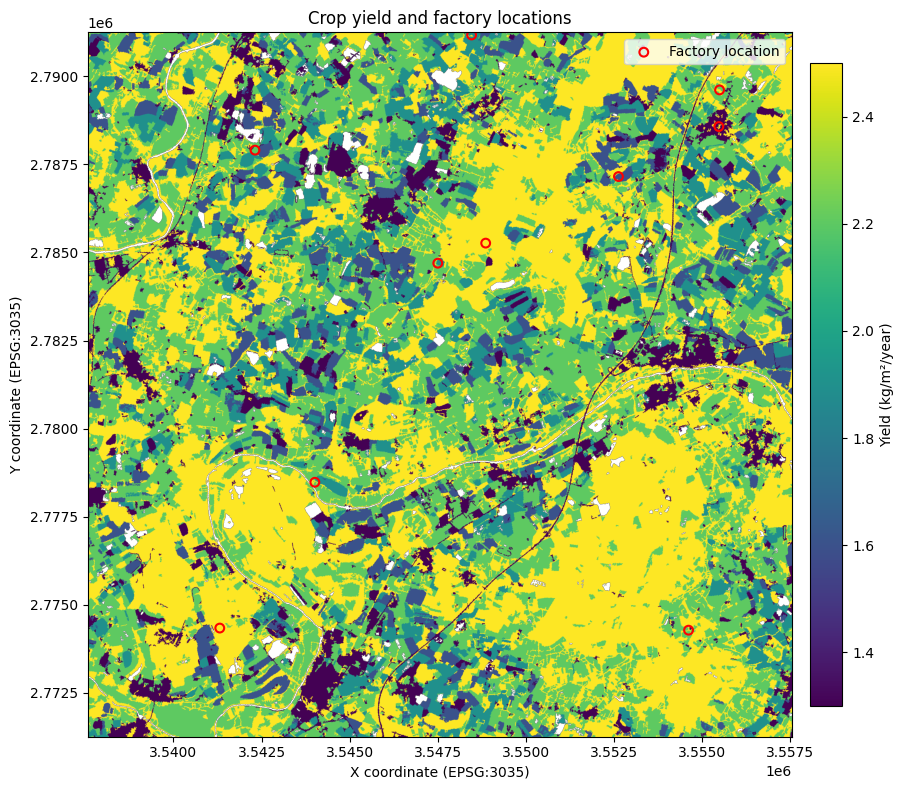

In [25]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

crop_raster_path     = "data/processed/EU_crop_map_yield.tif"
factory_raster_path  = "data/processed/factory_locations.tif"

# --- read crop/yield raster (background layer) ---
with rasterio.open(crop_raster_path) as src_crop:
    # band 2 = yield_kg_m2_year
    yield_band = src_crop.read(2)
    transform = src_crop.transform
    crs = src_crop.crs
    nodata_val = src_crop.nodata
    height = src_crop.height
    width = src_crop.width

# mask nodata / invalids for plotting
yield_masked = np.array(yield_band, copy=True).astype("float32")

if nodata_val is not None:
    yield_masked[yield_band == nodata_val] = np.nan
yield_masked[np.isnan(yield_masked)] = np.nan
# optional: hide zero-yield pixels if you want a cleaner map
# yield_masked[yield_masked <= 0] = np.nan

# --- read factory raster ---
with rasterio.open(factory_raster_path) as src_fac:
    factory_band = src_fac.read(1)
    fac_transform = src_fac.transform
    fac_crs = src_fac.crs

# sanity check alignment
assert fac_transform == transform, "Transform mismatch between rasters."
assert fac_crs == crs, "CRS mismatch between rasters."

# get (row, col) where factory == 1
fac_rows, fac_cols = np.where(factory_band == 1)

# convert those to map coordinates
factory_x = []
factory_y = []
for r, c in zip(fac_rows, fac_cols):
    x, y = transform * (c + 0.5, r + 0.5)  # pixel center
    factory_x.append(x)
    factory_y.append(y)

# --- compute extent for imshow ---
# upper-left corner of raster (col=0,row=0) and lower-right corner (col=width,row=height)
minx, maxy = transform * (0, 0)
maxx, miny = transform * (width, height)

extent = [minx, maxx, miny, maxy]

# If the data range is super skewed (like a few huge values),
# make the color scale robust using percentiles:
vmin = np.nanpercentile(yield_masked, 5)
vmax = np.nanpercentile(yield_masked, 95)

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    yield_masked,
    extent=extent,
    origin="upper",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Yield (kg/m²/year)")

ax.scatter(
    factory_x,
    factory_y,
    s=40,
    facecolors="none",
    edgecolors="red",
    linewidths=1.5,
    label="Factory location",
)

ax.set_title("Crop yield and factory locations")
ax.set_xlabel(f"X coordinate ({crs.to_string()})")
ax.set_ylabel(f"Y coordinate ({crs.to_string()})")

ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


## 4. Optimization

### Model for optimization
- create model using `references/Example_optimization_LCA.ipynb` as a reference

#### Set up LCA 
- connection to brightway 
- define impact calculation method 
- define scenarios (I still don't fully understand this step, will explore later)

In [90]:
target_dir = "results/lca"
os.makedirs(target_dir, exist_ok=True)

brightway_configuration_dictionary = {
    # path_to_folder_containing_the_bw_environment_and_packages_installed_there
    "path_to_brightway_project": "/Users/tsuitpy/Library/Application Support/Brightway3/biopol_lca.967046090aaaeb21fcd35d8654c4df5a", 
    "bw_project": "biopol_lca",
    "bw_database": "biopol_lca_database", 
    "bw_biosphere": "ecoinvent-3.9.1-biosphere",
    "bw_ecoinvent": "ecoinvent-3.9.1-cutoff"
}

methods_list = [
('TRACI v2.1', 'acidification', 'acidification potential (AP)'),
('TRACI v2.1', 'climate change', 'global warming potential (GWP100)'),
('TRACI v2.1', 'ecotoxicity: freshwater', 'ecotoxicity: freshwater'),
('TRACI v2.1', 'eutrophication', 'eutrophication potential'),
('TRACI v2.1', 'human toxicity: carcinogenic', 'human toxicity: carcinogenic'),
('TRACI v2.1', 'human toxicity: non-carcinogenic', 'human toxicity: non-carcinogenic'),
('TRACI v2.1', 'ozone depletion', 'ozone depletion potential (ODP)'),
('TRACI v2.1', 'particulate matter formation', 'particulate matter formation potential (PMFP)'),
('TRACI v2.1', 'photochemical oxidant formation', 'maximum incremental reactivity (MIR)'),
]
method_units_list = ['kg SO2-Eq',
 'kg CO2-Eq',
 'CTUe',
 'kg N-Eq',
 'CTUh',
 'CTUh',
 'kg CFC-11-Eq',
 'kg PM2.5-Eq',
 'kg O3-Eq',
]
methods_gp = methods_list[:]
impact_categories_names = ['AP', 'GWP100', 'ECFW', 'EP', 'HTC', 'HTNC', 'ODP', 'PMFP', 'MIR']

# In contrast to the simple LCA we now set the number of scenarios to a high number that basically represents the MC loops 
# The parametric model should now be set to include uncertainty for the MC loops. 
# This is done below, by setting a number of parameters to raneg with some probability distributions
scenarios = 100
timeframe = 1 #operational lifetime after construction
time_step = 1
construction_years = 0
number_of_infrastructure_processes = 0

#### Run parameterized LCA calculations 
- define bw keys for sub-sub-processes 
- map sub-sub-processes to sub-processes to main process 
- calculate LCA with `mpLCAer` 

In [91]:
keys_binder = {
    'b1_potato_starch_mass' : '8ce68e5f71f8f8c5dc50edb913e9cea1', # market for potato starch ('ecoinvent-3.9.1-cutoff', '8ce68e5f71f8f8c5dc50edb913e9cea1')
    'b2_lignin_resin_mass': '9ef63345ae414b0aa5683f09f4d0b806', # 'market for anionic resin' (kilogram, RER, None)
    'b3_soy_resin_mass': '16a6869a94ad2aaf84d113c88657406b' # 'market for phenolic resin' (kilogram, RER, None) 
}
keys_filler = {
    'f1_wood_fiber_mass' : 'd82e94ec45e662362de31d0ac344dc51', # 'market for wood wool' (kilogram, RER, None) 
    'f2_hemp_shiv_mass': 'b8b0f0ca4e8e1a99ddae3f6ae610be2e', # 'market for sunn hemp plant, harvested' (kilogram, GLO, None)
    'f3_rice_husk_mass': '94c1cb9e760faf73987ffea6c08cfcf1' # 'market for coconut husk' (kilogram, GLO, None) 
}
keys_recipe = {
    'binder': '', 
    'filler': '' 
}

key_list_sub_processes = [keys_binder, keys_filler]
mapping_names = create_mapping(keys_recipe, key_list_sub_processes)
unique_activities = create_list_with_unique_activities(key_list_sub_processes)

my_lca = mpLCAer(4, methods_gp, brightway_configuration_dictionary)
my_lca.import_isolated_environment()
my_lca.lca_calculations(mapping_names)

#### Define and test run model 

In [ ]:
import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point

class LocationModel:
    ''' 
    input: location (xy coordinates) 
    processing: get best recipe and impact of that location with RecipeModel() 
    output: environmental impact 
    '''

    def __init__(self, x, y):
        self.x = x
        self.y = y 
        return None
    
    def run(self): 
        # get availability of fillers 
        # optimize biopol recipe 
            # optimize proportion between fillers (if there are two)
            # optimize proportion between filler and binder
        return None 
    
class RecipeModel: 
    ''' 
    input: 
    - ingredient upper / lower limits 
    - filler availability

    processing: 
    - vary proportion between fillers (if there are two) 
    - vary proportion between fillers and binder 
    - find best option with pymoo 

    output: 
    - optimal biopol recipe (binder / filler amounts in kg)
    - environmental impact of this optimal recipe 
    '''
    None 

Playing around with the model

In [102]:
x=3537560.0
y=2791250.0
factory_point = Point(x, y)
raster_path = "data/processed/EU_crop_map_yield.tif"
conversion = pd.read_csv("data/processed/bipol_ranges_with_feedstocks.csv")
buffer_radius = 5000
nodata = None 

"""Crop raster and compute total yield per crop code."""
buffer_geom = factory_point.buffer(buffer_radius)
with rasterio.open(raster_path) as src:
    out_image, _ = mask(src, [buffer_geom], crop=True, indexes=[1, 3])
crop_band, yield_band = out_image[0], out_image[1]

if nodata is not None:
    valid = (crop_band != nodata) & (yield_band != nodata)
    crop_band, yield_band = crop_band[valid], yield_band[valid]

total_yield_per_crop = {
    int(c): float(yield_band[crop_band == c].sum())
    for c in np.unique(crop_band)
}


"""Map crop yield totals to ingredient availability and format as 2D np.arrays."""
ingredient_availability = {}
for _, row in conversion.iterrows():
    key = f"{row['id']}_{row['option']}_mass"
    crop_code = row['eu_crop_code']
    value = total_yield_per_crop.get(crop_code, 0.0)
    ingredient_availability[key] = np.array([[value]])  # ✅ ensure 2D array
ingredient_availability


"""Perform environmental impact calculation."""
# Extract 2D arrays
b1 = ingredient_availability['b1_potato_starch_mass']
b2 = ingredient_availability['b2_lignin_resin_mass']
b3 = ingredient_availability['b3_soy_resin_mass']
f1 = ingredient_availability['f1_wood_fiber_mass']
f2 = ingredient_availability['f2_hemp_shiv_mass']
f3 = ingredient_availability['f3_rice_husk_mass']

# Combine arrays elementwise
binder_mass = b1 + b2 + b3
filler_mass = f1 + f2 + f3
total_mass = binder_mass + filler_mass

binder_fracs = [b1 / binder_mass, b2 / binder_mass, b3 / binder_mass]
filler_fracs = [f1 / filler_mass, f2 / filler_mass, f3 / filler_mass]
mix_fracs = [binder_mass / total_mass, filler_mass / total_mass]

exchanges_list_sp = [binder_fracs, filler_fracs]
mapping_exchanges = create_mapping(keys_recipe, exchanges_list_sp)

calc = fast_calculator()
calc.calculation_static_lcia(mapping_exchanges, my_lca.unit_impacts)
calc.calculation_impact_senarios(mix_fracs, calc.impact, 'Biopol production')
calc.total_impact['Biopol production'][:, :, 0].T


array([[9.37097672e-03, 1.16002461e+00, 2.93674811e+01, 1.07484770e-02,
        9.77881968e-08, 1.38813806e-06, 1.73273367e-05, 8.51882643e-04,
        9.06623769e-02]])

In [121]:
keys_binder = {
    'b1_potato_starch_mass' : '8ce68e5f71f8f8c5dc50edb913e9cea1', # market for potato starch ('ecoinvent-3.9.1-cutoff', '8ce68e5f71f8f8c5dc50edb913e9cea1')
    'b2_lignin_resin_mass': '9ef63345ae414b0aa5683f09f4d0b806', # 'market for anionic resin' (kilogram, RER, None)
    'b3_soy_resin_mass': '16a6869a94ad2aaf84d113c88657406b' # 'market for phenolic resin' (kilogram, RER, None) 
}
keys_filler = {
    'f1_wood_fiber_mass' : 'd82e94ec45e662362de31d0ac344dc51', # 'market for wood wool' (kilogram, RER, None) 
    'f2_hemp_shiv_mass': 'b8b0f0ca4e8e1a99ddae3f6ae610be2e', # 'market for sunn hemp plant, harvested' (kilogram, GLO, None)
    'f3_rice_husk_mass': '94c1cb9e760faf73987ffea6c08cfcf1' # 'market for coconut husk' (kilogram, GLO, None) 
}
keys_recipe = {
    'binder': '', 
    'filler': '' 
}

key_list_sub_processes = [keys_binder, keys_filler]
mapping_names = create_mapping(keys_recipe, key_list_sub_processes)
unique_activities = create_list_with_unique_activities(key_list_sub_processes)

my_lca = mpLCAer(4, methods_gp, brightway_configuration_dictionary)
my_lca.import_isolated_environment()
my_lca.lca_calculations(mapping_names)

In [122]:
# model biopol recipe separately as its own dictionary and list 
key_recipe = {
    'Recipe Production': ''
}
exchange_list_recipe = [1] # 1kg of biopol ingredients = 1kg of printed biopol (for now, simple example)

# model other sub-process(s) - in our case, transportation 
transportation_distance_km = 10 # defined by spatial analysis 
key_transportation = {
    'transportation': '9f5ff656ecdc15acd23085211786936f' 
}
exchange_list_transportation = [transportation_distance_km]

# model new main process - biopol 3d print production 
key_biopol_3dprint_production = {
    'Transportation': '', 
}
exchange_list_biopol_3dprint_production = [1]


In [123]:
key_list_new_main_process = [key_transportation]
exchanges_list_new_main_process = [exchange_list_transportation]

mapping_new_main_process = create_mapping(key_biopol_3dprint_production, key_list_new_main_process)
unique_activities_new_main_process = create_list_with_unique_activities(key_list_new_main_process)
mapping_each_new_main_process = create_mapping(key_biopol_3dprint_production, exchanges_list_new_main_process)

my_lca_new_main_process = mpLCAer(4, methods_gp, brightway_configuration_dictionary)
my_lca_new_main_process.import_isolated_environment()
my_lca_new_main_process.lca_calculations(mapping_new_main_process)


In [126]:
calc = fast_calculator()
calc.calculation_static_lcia(mapping_new_main_process, my_lca_new_main_process.unit_impacts)
calc.calculation_impact_senarios(mix_fracs, calc.impact, 'Biopol production')
calc.total_impact['Biopol production'][:, :, 0].T

AttributeError: 'str' object has no attribute 'shape'

In [124]:
my_lca_new_main_process.unit_impacts

{'Transportation': array([[4.16404006e-04, 1.41896635e-01, 1.28912783e+00, 1.14120326e-04,
         1.03015172e-08, 3.31454746e-08, 3.34497549e-09, 7.58738798e-05,
         1.08835144e-02]])}

In [ ]:
# make mapping_exchanges 
keys_biopol = {
    'transportation': '', 
    'recipe': '', 
}
transportation_fracs = [1.]
recipe_fracs = mix_fracs # fraction of binder vs filler
exchanges_list_sp = [transportation_fracs, recipe_fracs]
mapping_exchanges = create_mapping(keys_biopol, exchanges_list_sp)

# re-calculate my_lca (adding transportation)
my_lca = mpLCAer(4, methods_gp, brightway_configuration_dictionary)
my_lca.import_isolated_environment()
my_lca.lca_calculations(mapping_names)

# # remake fast_calculator() 
# calc = fast_calculator()
# calc.calculation_static_lcia(mapping_exchanges, my_lca.unit_impacts)
# calc.calculation_impact_senarios(mix_fracs, calc.impact, 'Biopol production')
# calc.total_impact['Biopol production'][:, :, 0].T

{'transportation': [1.0],
 'recipe': [array([[0.52903226]]), array([[0.47096774]])]}

In [96]:
model = AdaptiveFactoryModel(
    raster_path="data/processed/EU_crop_map_yield.tif",
    conversion_csv="data/processed/bipol_ranges_with_feedstocks.csv", 
    buffer_radius=1000
)
result = model.run(x=3537560.0, y=2791250.0)
print(result)

[[4.50456073e-03 1.02513874e+00 1.59470857e+01 5.74334696e-03
  7.11017623e-08 4.51412629e-07 4.08661011e-05 4.58478542e-04
  5.30993265e-02]]


### Single objective optimization 

In [111]:
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.optimize import minimize 
import rasterio

# 1. Define bounds for adaptive factory coordinates
path = "data/processed/EU_crop_map_yield.tif"
with rasterio.open(path) as src:
    bounds = src.bounds

low_bounds = np.array([bounds.left, bounds.bottom])   # (x_min, y_min)
high_bounds = np.array([bounds.right, bounds.top])    # (x_max, y_max)

# 2. Define optimization problem
class Single(ElementwiseProblem):
    def __init__(self, model, buffer_radius=5000):
        self.model = model
        self.buffer_radius = buffer_radius
        super().__init__(
            n_var=2,              # two decision variables: x and y
            n_obj=1,              # single objective
            xl=low_bounds,        # lower bounds
            xu=high_bounds,       # upper bounds
            elementwise_evaluation=True
        )

    def _evaluate(self, x, out, *args, **kwargs):
        loc_x, loc_y = x

        # Run model at the given coordinates
        try:
            gsa_result = self.model.run(x=loc_x, y=loc_y, buffer_radius=self.buffer_radius)
            # Assuming gsa_result is a 2D numpy array and you want to minimize a scalar (e.g., total impact)
            objective_value = np.sum(gsa_result)
        except Exception as e:
            # Handle invalid areas (e.g. outside raster)
            print(f"Warning: evaluation failed at ({loc_x}, {loc_y}): {e}")
            objective_value = np.inf

        out["F"] = objective_value


# 3. Create model instance once (reuse across generations)
model = AdaptiveFactoryModel(
    raster_path="data/processed/EU_crop_map_yield.tif",
    conversion_csv="data/processed/bipol_ranges_with_feedstocks.csv"
)

# 4. Run optimization
problem = Single(model, buffer_radius=5000)
algorithm = GA(pop_size=50)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 10),
    seed=42,
    verbose=True,
    save_history=True 
)

# 5. Inspect results
print("\nBest factory location:")
print(f"x: {res.X[0]:.2f}, y: {res.X[1]:.2f}")
print(f"Objective value: {res.F[0]:.2f}")


n_gen  |  n_eval  |     f_avg     |     f_min    
     1 |       50 |  3.443939E+01 |  2.733514E+01
     2 |      100 |  3.010696E+01 |  2.705345E+01
     3 |      150 |  2.843307E+01 |  2.653591E+01
     4 |      200 |  2.747976E+01 |  2.653591E+01
     5 |      250 |  2.706466E+01 |  2.632473E+01
     6 |      300 |  2.673006E+01 |  2.622744E+01
     7 |      350 |  2.649952E+01 |  2.622744E+01
     8 |      400 |  2.636283E+01 |  2.622744E+01
     9 |      450 |  2.628159E+01 |  2.618598E+01
    10 |      500 |  2.625171E+01 |  2.618304E+01

Best factory location:
x: 3543048.86, y: 2791249.84
Objective value: 26.18


#### Visualize

In [112]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point, mapping

def visualize_optimization_progress(problem, res, generations_to_plot, buffer_radius=5000):
    """Visualize optimization progress and show local yield density at best locations."""
    
    # Read base raster background (band 1 just for context)
    with rasterio.open(problem.model.raster_path) as src:
        background = src.read(1)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
        crs = src.crs

    n_generations = len(res.history)
    generations_to_plot = [g for g in generations_to_plot if g < n_generations]

    if not generations_to_plot:
        print(f"⚠️ No valid generations to plot (max available: {n_generations-1}).")
        return

    fig, axes = plt.subplots(1, len(generations_to_plot), figsize=(5 * len(generations_to_plot), 6))
    if len(generations_to_plot) == 1:
        axes = [axes]

    for ax, gen in zip(axes, generations_to_plot):
        history_gen = res.history[gen].opt
        F_values = np.array(history_gen.get("F")).flatten()
        X_values = np.array(history_gen.get("X"))

        if F_values.size == 0 or X_values.size == 0:
            print(f"⚠️ Skipping generation {gen} (no data).")
            continue

        best_idx = np.argmin(F_values)
        best_x, best_y = X_values[best_idx]
        best_F = float(np.squeeze(F_values[best_idx]))

        # --- Run your model again at best location ---
        try:
            # Extract the local raster window for visualization (band 3: yield)
            with rasterio.open(problem.model.raster_path) as src:
                buffer_geom = Point(best_x, best_y).buffer(buffer_radius)
                out_image, out_transform = mask(src, [mapping(buffer_geom)], crop=True, indexes=[3])
                yield_local = out_image[0]
                yield_local = np.where(yield_local == -9999, np.nan, yield_local)

            # Compute total yield in the cropped area
            total_yield = float(np.nansum(yield_local))  # in kg
            total_yield_tons = total_yield / 1e6
        except Exception as e:
            print(f"⚠️ Could not extract local raster for generation {gen}: {e}")
            yield_local = None
            total_yield_tons = np.nan

        # --- Plot ---
        ax.imshow(background, extent=extent, origin="upper", cmap="Greens")
        ax.set_title(
            f"Gen {gen}\nBest F = {best_F:.2f}\nTotal yield = {total_yield_tons:.2f} t",
            fontsize=11
        )
        ax.set_xlabel("X (m)")
        ax.set_ylabel("Y (m)")

        # Plot best factory + buffer
        ax.scatter(best_x, best_y, color="red", s=60, label="Factory")
        circle = Circle((best_x, best_y), buffer_radius, fill=False, edgecolor="red", linewidth=2)
        ax.add_patch(circle)
        ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()


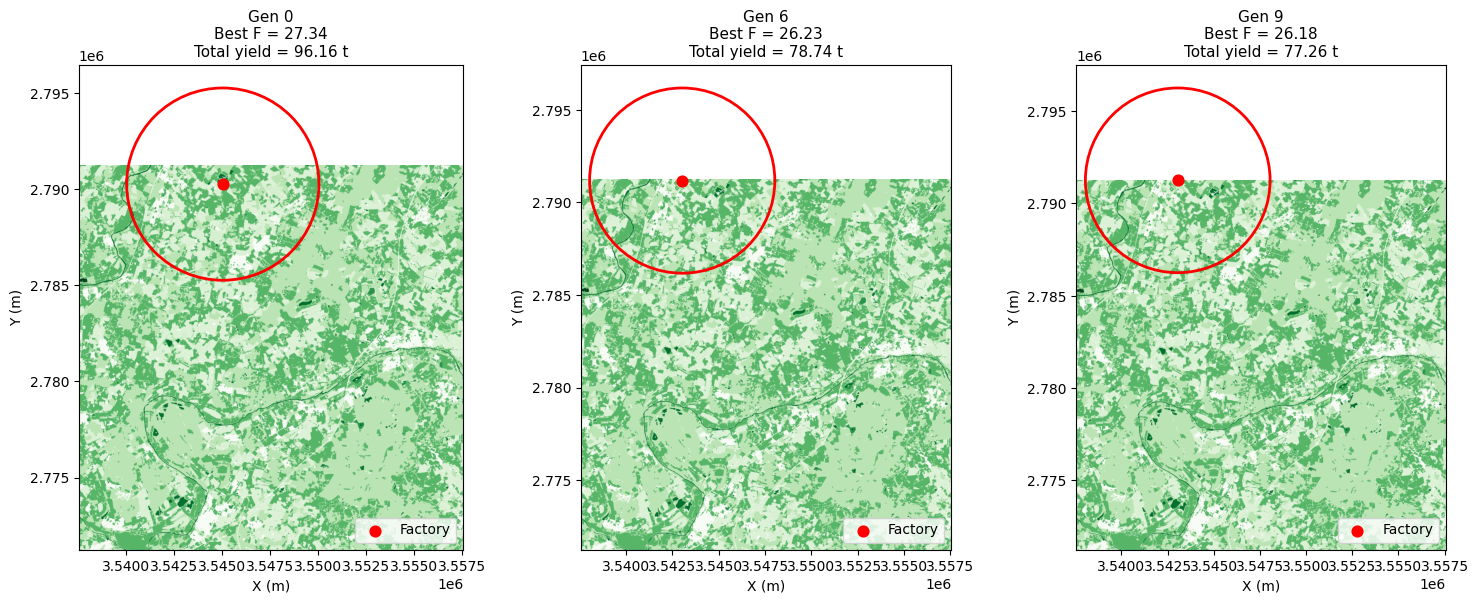

In [113]:
generations_to_plot = [0, 6, 9]
visualize_optimization_progress(problem, res, generations_to_plot, buffer_radius=5000)


### Multi objective optimization

In [ ]:
class Multi(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=6,
            n_obj=2,
            n_constr=0,
            xl=low_bounds,
            xu=high_bounds,
            elementwise_evaluation=True
        )

    def _evaluate(self, x, out, *args, **kwargs):

        b1_potato_starch_mass, b2_lignin_resin_mass, b3_soy_resin_mass, f1_wood_fiber_mass, f2_hemp_shiv_mass, f3_rice_husk_mass = [np.array([value]).reshape((1,1)) for value in x]

        F = model(b1_potato_starch_mass, b2_lignin_resin_mass, b3_soy_resin_mass, f1_wood_fiber_mass, f2_hemp_shiv_mass, f3_rice_husk_mass)

        out["F"] = F[0, :2]

In [38]:
mo_problem = Multi()
mo_algo    = NSGA2(pop_size=100)
mo_res     = minimize(
    mo_problem,
    mo_algo,
    ('n_gen', 200),
    seed=42,
    verbose=True
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |      4 |             - |             -
     2 |      200 |      7 |  0.0227758570 |         ideal
     3 |      300 |      5 |  0.0963057622 |         ideal
     4 |      400 |      9 |  0.0689113714 |         ideal
     5 |      500 |      2 |  0.7261325384 |         ideal
     6 |      600 |      5 |  0.3235239240 |         ideal
     7 |      700 |      6 |  0.0748786920 |             f
     8 |      800 |      7 |  0.2299538384 |         ideal
     9 |      900 |      6 |  0.1998372845 |         ideal
    10 |     1000 |      8 |  0.0446782160 |         ideal
    11 |     1100 |      5 |  0.5053507880 |         ideal
    12 |     1200 |      8 |  0.0290791714 |         ideal
    13 |     1300 |      8 |  0.0198840537 |         ideal
    14 |     1400 |     11 |  0.0815174445 |         ideal
    15 |     1500 |     12 |  0.0391894557 |         ideal
    16 |     1600 |     13 |  0.1120723767 |         ide